In [ ]:
!pip install wfdb

## Concepto clave

PhysioNet organiza los datos como:

- record → señal (ej: ECG)
- annotation → etiquetas (ej: latidos, arritmias)
- metadata → frecuencia de muestreo, unidades, etc.

## Descargar y cargar un registro

Ejemplo con el dataset clásico:

- MIT-BIH Arrhythmia Database

In [ ]:
import wfdb

# Descargar un registro (ej: 100)
record = wfdb.rdrecord('100', pn_dir='mitdb')

# Read a WFDB anno tation file record_name.extension and return an Annotation
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

# Tipo: numpy array
# Forma: (N, canales)
signal = record.p_signal
fs = record.fs

In [ ]:
import wfdb

In [ ]:
#wfdb.get_dbs()

In [ ]:
help(wfdb.io)

Help on package wfdb.io in wfdb:

NAME
    wfdb.io

PACKAGE CONTENTS
    _coreio
    _header
    _signal
    _url
    annotation
    convert (package)
    datasource
    download
    header
    record
    util

DATA
    SIGNAL_CLASSES =                   description   unit_scale      ...no...

FILE
    /usr/local/lib/python3.12/dist-packages/wfdb/io/__init__.py




The annotation.symbol attribute provides a list of classifications for each detected event (usually a heartbeat) in the ECG signal. For the MIT-BIH Arrhythmia Database, these symbols have specific meanings:

- N: Normal beat
- +: R-on-T premature ventricular contraction (not a beat, but marks a rhythm change or non-beat event, in this context specifically used as lead switch)
- A: Atrial premature beat

There are many other symbols representing various types of beats and events (e.g., V for premature ventricular contraction, ! for ventricular flutter wave). A comprehensive list is usually available in the documentation for the specific PhysioNet database you are using. These annotations are crucial for identifying and studying different cardiac arrhythmias.

In [ ]:
# https://archive.physionet.org/physiobank/database/records.shtml
# recordx = wfdb.rdrecord('118e00', pn_dir='nstdb')
# signalx = recordx.p_signal
# plt.plot(signalx[:2000,0])

In [ ]:
annotation.sample, annotation.symbol, annotation.aux_note

(array([    18,     77,    370, ..., 649484, 649734, 649991]),
 ['+',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'A',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',
  'N',

In [ ]:
signal, signal.shape

(array([[-0.145, -0.065],
        [-0.145, -0.065],
        [-0.145, -0.065],
        ...,
        [-0.675, -0.365],
        [-0.765, -0.335],
        [-1.28 ,  0.   ]]),
 (650000, 2))

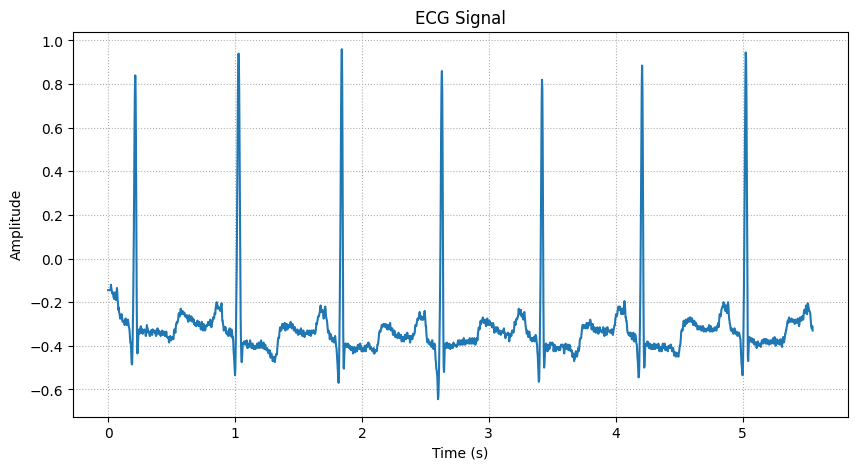

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N = signal.shape[0]
n = np.arange(N)
t = n/fs

plt.figure(figsize=(10,5))
plt.plot(t[:2000], signal[:2000,0])
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

(array([3.02113842e-01, 1.49469258e-01, 2.70611940e-03, ...,
        2.26320732e-05, 1.89662798e-05, 1.08328515e-05]),
 array([0.00000000e+00, 5.53846154e-04, 1.10769231e-03, ...,
        1.79998892e+02, 1.79999446e+02, 1.80000000e+02]),
 <matplotlib.lines.Line2D at 0x792fb98449e0>)

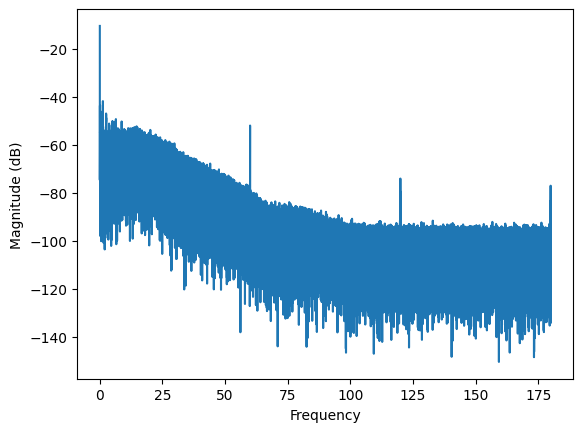

In [ ]:
x = signal[:,0]

plt.magnitude_spectrum(x, Fs=fs, scale='dB')

(array([4.18513507e-03, 5.11753626e-03, 2.70619041e-03, ...,
        2.26320732e-05, 1.89662798e-05, 1.08328515e-05]),
 array([0.00000000e+00, 5.53846154e-04, 1.10769231e-03, ...,
        1.79998892e+02, 1.79999446e+02, 1.80000000e+02]),
 <matplotlib.lines.Line2D at 0x792fbad55490>)

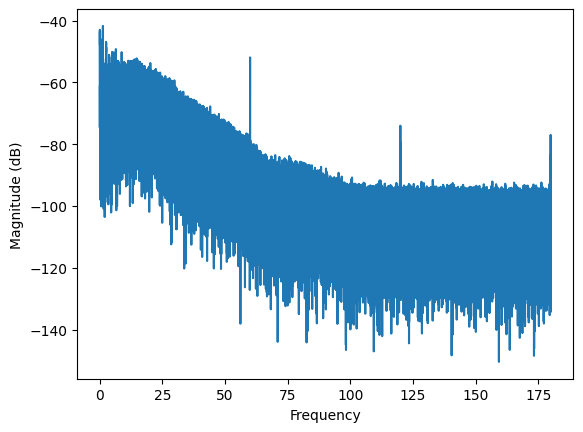

In [ ]:
x_dc_removed = x - np.mean(x)

plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')

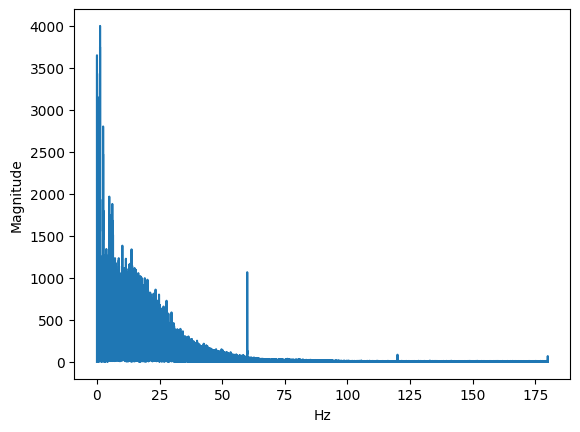

In [ ]:

X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

plt.plot(freqs[:len(x_dc_removed)//2], np.abs(X[:len(x_dc_removed)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

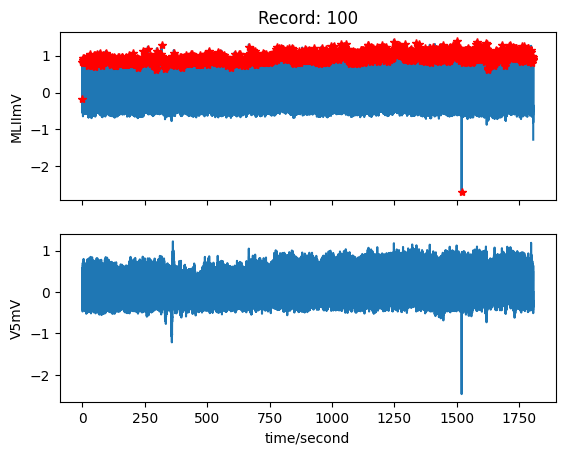

In [ ]:
wfdb.plot_wfdb(record=record, annotation=annotation)

## filtro pasa banda con

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass(signal, fs, low=0.5, high=40):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass(signal[:,0], fs)

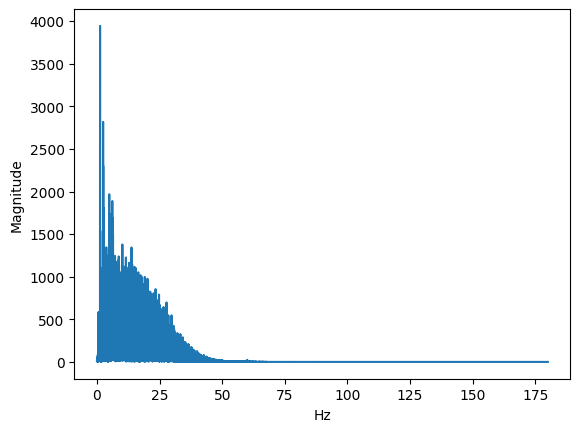

In [ ]:
X = np.fft.fft(filtered)
freqs = np.fft.fftfreq(len(filtered), 1/fs)

plt.plot(freqs[:len(filtered)//2], np.abs(X[:len(filtered)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

## Segmentación (ventanas)

In [ ]:
window_size = int(2 * fs)  # 2 segundos
segments = []

for i in range(0, len(filtered)-window_size, window_size):
    segments.append(filtered[i:i+window_size])

## Feature extraction

In [ ]:
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment)
    ]

In [ ]:
extract_features(segments[0])

[np.float64(-0.0022378178147655354),
 np.float64(0.18272426668731304),
 np.float64(1.240992815187943)]

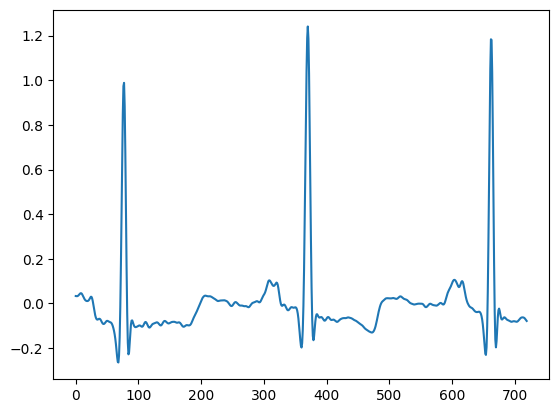

In [ ]:
plt.plot(segments[0])

ACTIVIDAD 2: Cargar 3 bases de datos de PhysioNet

In [ ]:
# lectura de MIT-BIH Normal Sinus Rhythm Database
import wfdb

# Descargar un registro (ej: 16265)
record = wfdb.rdrecord('16265', pn_dir='nsrdb')

# Read a WFDB annotation file record_name.extension and return an Annotation
annotation = wfdb.rdann('16265', 'atr', pn_dir='nsrdb')

# Tipo: numpy array
# Forma: (N, canales)
signal = record.p_signal
fs = record.fs

In [ ]:
signal, signal.shape

(array([[-0.165, -0.325],
        [-0.155, -0.325],
        [-0.195, -0.305],
        ...,
        [-0.05 , -0.095],
        [-0.05 , -0.085],
        [-0.05 , -0.085]]),
 (11730944, 2))

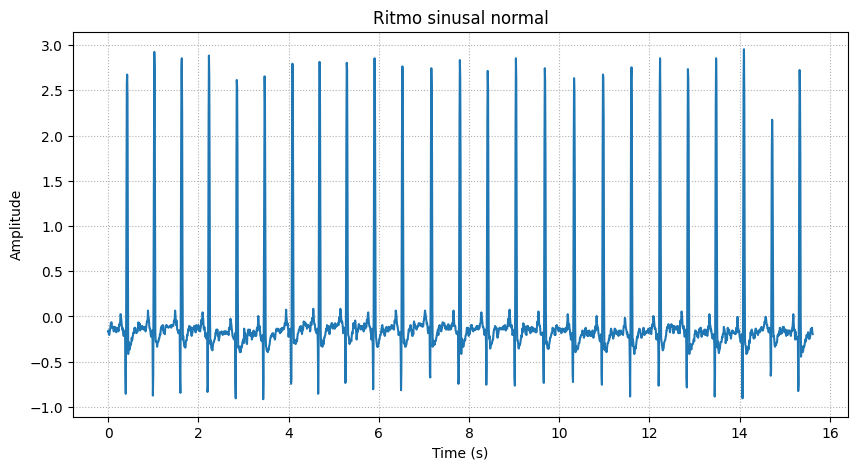

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

N = signal.shape[0]
n = np.arange(N)
t = n/fs

plt.figure(figsize=(10,5))
plt.plot(t[:2000], signal[:2000,0])
plt.title("Ritmo sinusal normal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

In [ ]:
# Descargar un registro
record = wfdb.rdrecord('118e06', pn_dir='nstdb')

# Read a WFDB annotation file record_name.extension and return an Annotation
annotation = wfdb.rdann('118e06', 'atr', pn_dir='nstdb')

# Tipo: numpy array
# Forma: (N, canales)
signal2 = record.p_signal
fs2 = record.fs

In [ ]:
signal2, signal2.shape

(array([[ -5.955,  -5.635],
        [ -5.955,  -5.635],
        [ -5.955,  -5.635],
        ...,
        [ -1.98 ,  -9.285],
        [ -1.925,  -9.325],
        [ -7.04 , -14.44 ]]),
 (650000, 2))

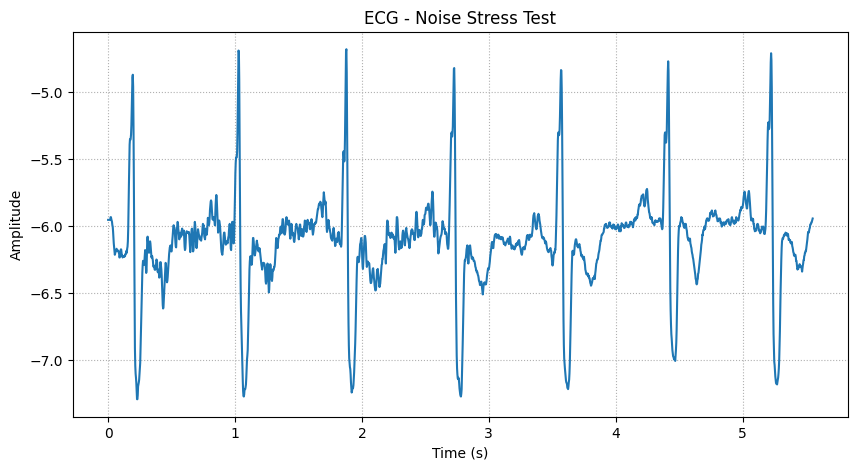

In [ ]:
N2 = signal2.shape[0]
n2 = np.arange(N2)
t2 = n2/fs2

plt.figure(figsize=(10,5))
plt.plot(t2[:2000], signal2[:2000,0])
plt.title("ECG - Noise Stress Test")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

In [ ]:
#3
# lectura de MIT-BIH Polysomnographic Database
import wfdb

# Descargar un registro
record = wfdb.rdrecord('slp01a', pn_dir='slpdb')

# Read a WFDB annotation file record_name.extension and return an Annotation
annotation = wfdb.rdann('slp01a', 'st', pn_dir='slpdb')

# Tipo: numpy array
# Forma: (N, canales)
signal3 = record.p_signal
fs3 = record.fs

In [ ]:
signal3, signal3.shape

(array([[ 8.50000000e-02,  4.79302103e+01, -3.91912908e-02,
         -2.60869565e-01],
        [ 8.00000000e-02,  4.77209080e+01, -3.88802488e-02,
         -2.66666667e-01],
        [ 1.25000000e-01,  4.79302103e+01, -3.85692068e-02,
         -2.60869565e-01],
        ...,
        [ 2.30000000e-01,  7.86976378e+01,  1.47278383e-01,
          3.82608696e-01],
        [ 2.35000000e-01,  8.20464735e+01,  1.46811820e-01,
          3.81159420e-01],
        [ 2.25000000e-01,  8.56046113e+01,  1.42612753e-01,
          3.76811594e-01]]),
 (1800000, 4))

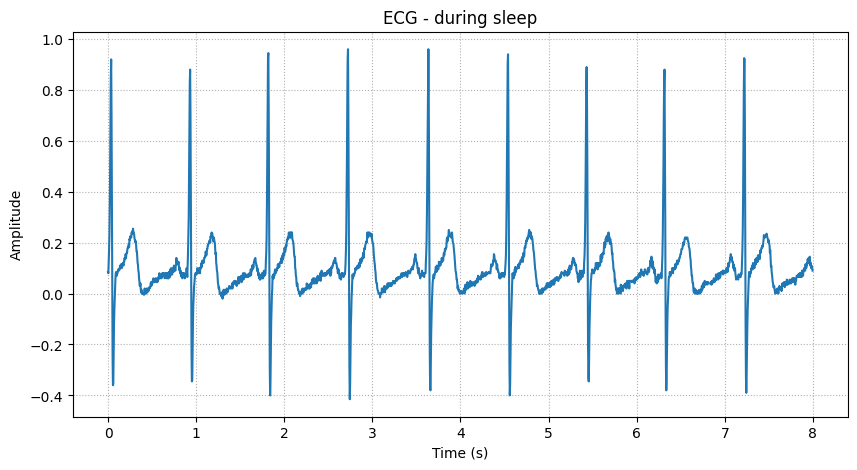

In [ ]:

N3 = signal3.shape[0]
n3 = np.arange(N3)
t3 = n3/fs3

plt.figure(figsize=(10,5))
plt.plot(t3[:2000], signal3[:2000,0])
plt.title("ECG - during sleep")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()